In [1]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import utils
import nist_codes

try:
    import nist_helper
    descriptor_tokens = [t.lower() for t in getattr(nist_helper, "NIST_DESCRIPTORS", [])]
except Exception:
    nist_helper = None
    descriptor_tokens = []

In [2]:
HE_SHEET = "he test.xlsx"

df = pd.read_excel(HE_SHEET)
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

# Sort by 'nm' to ensure correct neighbor comparison and plotting order
df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  


In [3]:
rgb = utils.wavelength_to_rgb

y_title = 'Intensity'
x_title = 'Wavelength (nm)'
fig_size = (15,6)
prominence = 0.12
min_bright = 0.1
min_alpha = 0.1
gamma_factor = 0.8
bar_width = 1
smoothing_window = 5    # Increase this value to control the degree of smoothing
base_sigma_nm = 0.5 # Base width of the Gaussian (for low intensity peaks)
max_sigma_multiplier = 4.0 # How much wider the highest intensity peaks can be
x_min = 400
x_max = 750
mode = 'dark'
reverse_x = True
show_grid = True
plot_type = None

df_filtered['Smoothed_int'] = df_filtered['Grey Val'].rolling(window=smoothing_window, center=True).mean().fillna(df_filtered['Grey Val'])

if plot_type == 'Smoothed':
    min_int = df_filtered['Smoothed_int'].min
    max_int = df_filtered['Smoothed_int'].max
else:
    min_int = df_filtered['Grey Val'].min()
    max_int = df_filtered['Grey Val'].max()

int_range = max_int - min_int

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    if plot_type == 'Smoothed':
        df_filtered['Normalized_int'] = (df_filtered['Smoothed_int'] - min_int) / int_range
    else:
        df_filtered['Normalized_int'] = (df_filtered['Grey Val'] - min_int) / int_range

In [4]:
def axis_labels():
    ax = plt.gca()

    if mode == 'dark':
        fig_bg = 'black'
        text = 'white'
        plt.gcf().set_facecolor('black')
        if show_grid is True:
            plt.grid(show_grid, color='darkgrey', linestyle=':', linewidth=0.5)
    else:
        fig_bg = 'white'
        text = 'black'
        if show_grid is True:
            plt.grid(show_grid)
    
    if reverse_x is True:
        plt.xlim(x_max, x_min)
    else:
        plt.xlim(x_min, x_max)

    ax.set_facecolor(fig_bg)
    plt.xlabel(x_title, color=text)
    plt.ylabel(y_title, color=text)
    plt.xticks(color=text)
    plt.yticks(color=text)

In [5]:
def dynamic_prominence(prominence, int_range):
    dyn_prom = prominence * int_range
    return dyn_prom

In [6]:
def final_alpha(alpha_min, alpha_factor):
    final_alpha = alpha_min + (1 - alpha_min) * alpha_factor
    return final_alpha

In [7]:
def final_int_scale(int_factor):
    final_intensity_scale = min_bright + (1 - min_bright) * int_factor
    return final_intensity_scale

In [8]:
def colored_rgb(base_rgb, final_intensity_scale):
    colored_rgb = (base_rgb[0] * final_intensity_scale,
                   base_rgb[1] * final_intensity_scale,
                   base_rgb[2] * final_intensity_scale)
    return colored_rgb

In [14]:
def gaussian_iteration():
    df_plot_data = df_filtered[(df_filtered['nm'] >= 400) & (df_filtered['nm'] <= 750)].copy()
    df_plot_data = df_plot_data.sort_values(by='nm').reset_index(drop=True)

    # Detect peaks
    dyn_prominence = dynamic_prominence(prominence, int_range)
    peaks_indices, properties = find_peaks(df_plot_data['Grey Val'], prominence=dyn_prominence)

    # Create a new, denser wavelength array for plotting the synthetic spectrum
    x_synthetic = np.linspace(400, 750, 1000) # 1000 points for a smooth synthetic curve
    y_synthetic = np.zeros_like(x_synthetic)

    for i, peak_idx in enumerate(peaks_indices):
        peak_nm = df_plot_data.iloc[peak_idx]['nm']
        peak_amplitude = df_plot_data.iloc[peak_idx]['Grey Val']
        normalized_amplitude = df_plot_data.iloc[peak_idx]['Normalized_int']

        # Scale sigma based on normalized intensity (higher intensity = broader peak)
        sigma = base_sigma_nm + (max_sigma_multiplier - 1) * base_sigma_nm * normalized_amplitude

        # Create a Gaussian curve for this peak
        gaussian_curve = peak_amplitude * np.exp(-((x_synthetic - peak_nm)**2) / (2 * sigma**2))
        y_synthetic += gaussian_curve # Add to the total synthetic spectrum

    # Normalize the synthetic spectrum intensities for coloring (if desired, not strictly necessary for area plot)
    min_y_synthetic = y_synthetic.min()
    max_y_synthetic = y_synthetic.max()
    if (max_y_synthetic - min_y_synthetic) == 0:
        normalized_y_synthetic = np.ones_like(y_synthetic)
    else:
        normalized_y_synthetic = (y_synthetic - min_y_synthetic) / (max_y_synthetic - min_y_synthetic)

        # Iterate through each segment of the synthetic spectrum to apply color and alpha
    for i in range(len(x_synthetic) - 1):
        wavelength_start = x_synthetic[i]
        wavelength_end = x_synthetic[i+1]

        base_rgb = rgb(wavelength_start, gamma=gamma_factor)

        alpha = final_alpha(min_alpha, normalized_y_synthetic[i])

        plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0],
                        [y_synthetic[i], y_synthetic[i+1]],
                        color=base_rgb,
                        alpha=alpha,
                        linewidth=0)
        

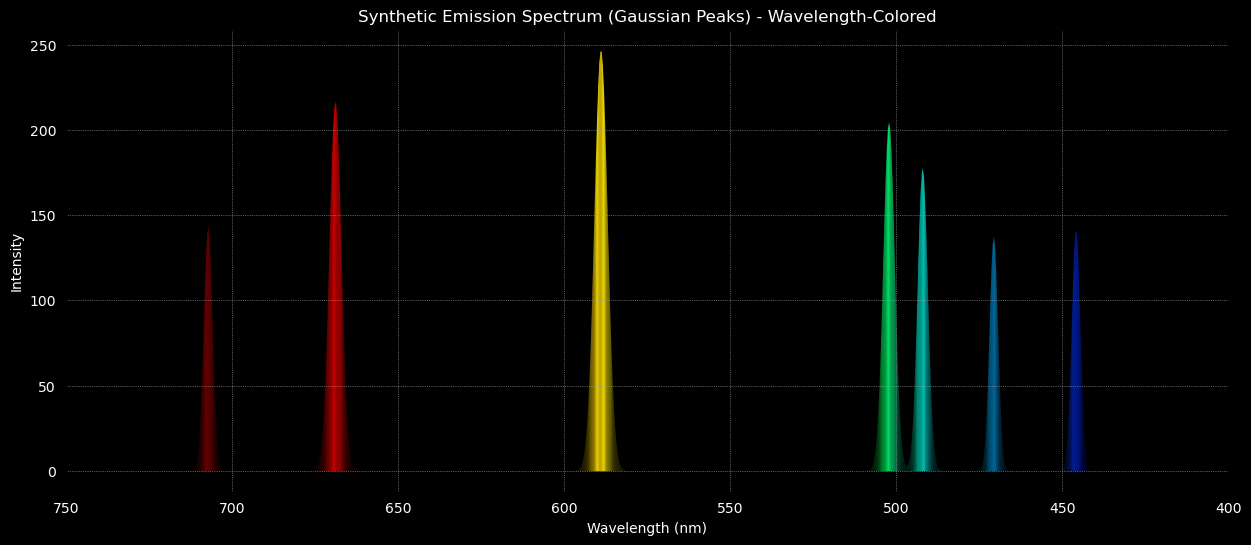

This visualization constructs a synthetic emission spectrum by representing each detected peak as a Gaussian curve.
The amplitude of each Gaussian corresponds to the peak's intensity, and its width is also scaled by intensity, simulating line broadening.
The resulting smooth, continuous curve is colored by wavelength, with opacity adjusted by the synthetic intensity, creating a soft, glowing effect.


In [15]:
mode = 'dark'

# Create the plot
plt.figure(figsize=(15, 6))
axis_labels()
gaussian_iteration()

plt.title('Synthetic Emission Spectrum (Gaussian Peaks) - Wavelength-Colored', color='white')
plt.show()

print("This visualization constructs a synthetic emission spectrum by representing each detected peak as a Gaussian curve.")
print("The amplitude of each Gaussian corresponds to the peak's intensity, and its width is also scaled by intensity, simulating line broadening.")
print("The resulting smooth, continuous curve is colored by wavelength, with opacity adjusted by the synthetic intensity, creating a soft, glowing effect.")